In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

sns.set_style("whitegrid")

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame          # full dataframe with features + target
df['diagnosis'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

print(df.shape)          # (569, 32) -> 569 patients, 30 features + target
df.head()

(569, 32)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


In [3]:
df.info()                     # column types, non-null counts
df.describe()                 # mean, std, min, max per feature
df.isnull().sum().sum()       # check for missing values (should be 0 here)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

np.int64(0)

In [4]:
print("Duplicate rows:", df.duplicated().sum())
# - class balance (important for later ML step too)
print(df['diagnosis'].value_counts())

Duplicate rows: 0
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64


/tmp/ipykernel_604/3907484586.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='diagnosis', palette=['#2c7fb8', '#e34a33'])


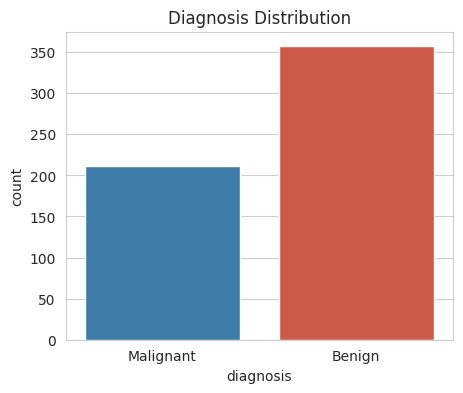

In [5]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='diagnosis', palette=['#2c7fb8', '#e34a33'])
plt.title("Diagnosis Distribution")
plt.savefig("chart1_class_balance.png", dpi=150, bbox_inches='tight')
plt.show()

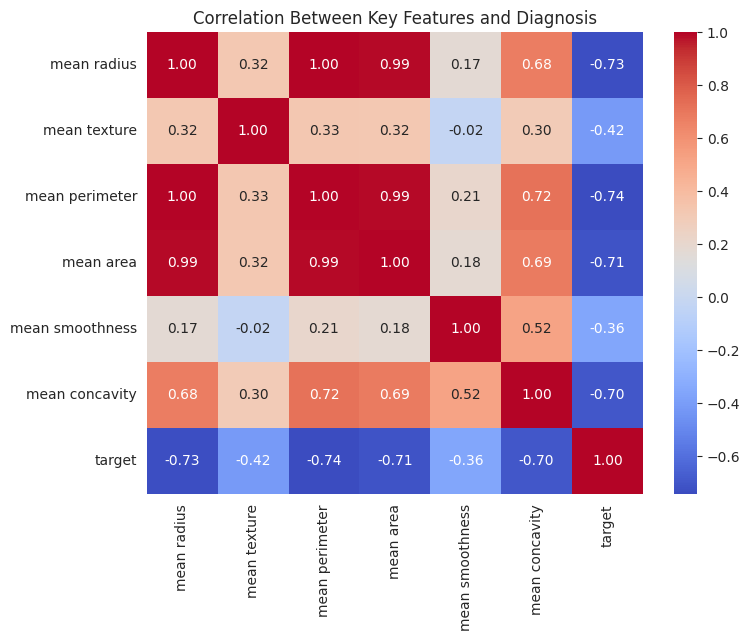

In [6]:
top_features = ['mean radius', 'mean texture', 'mean perimeter',
                 'mean area', 'mean smoothness', 'mean concavity', 'target']
plt.figure(figsize=(8,6))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Key Features and Diagnosis")
plt.savefig("chart2_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_604/3952296901.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y='mean radius', palette=['#2c7fb8', '#e34a33'])


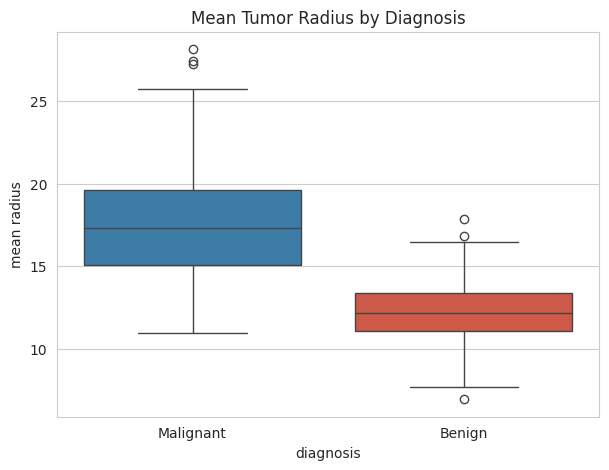

In [7]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='diagnosis', y='mean radius', palette=['#2c7fb8', '#e34a33'])
plt.title("Mean Tumor Radius by Diagnosis")
plt.savefig("chart3_radius_by_diagnosis.png", dpi=150, bbox_inches='tight')
plt.show()

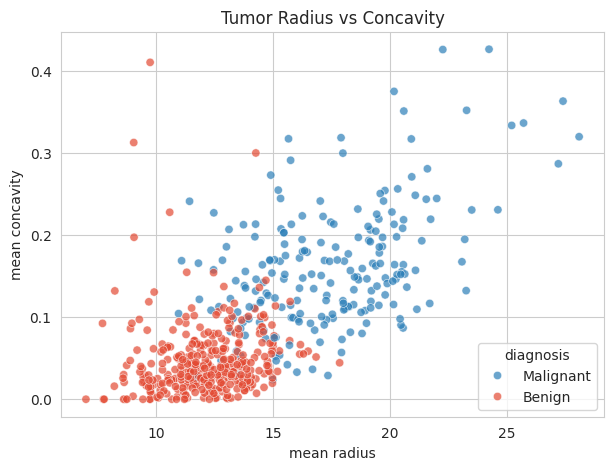

In [8]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='mean radius', y='mean concavity',
                 hue='diagnosis', palette=['#2c7fb8', '#e34a33'], alpha=0.7)
plt.title("Tumor Radius vs Concavity")
plt.savefig("chart4_radius_vs_concavity.png", dpi=150, bbox_inches='tight')
plt.show()

In [9]:
df.to_csv("breast_cancer_cleaned.csv", index=False)
print("Saved cleaned dataset and 4 charts.")


Saved cleaned dataset and 4 charts.
